# UnCLIP: The Model Behind OpenAI's DALL·E 2

In this tutorial, we will walk through how to build and train an **UnCLIP model** using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) diffusion library. TorchDiff is a flexible diffusion framework built on top of [PyTorch](https://pytorch.org/), and this tutorial focuses on the **UnCLIP architecture (DALL·E 2)**, as introduced in the paper:  
[Hierarchical Text-Conditional Image Generation with CLIP Latents](https://arxiv.org/abs/2204.06125).

This notebook trains the **complete UnCLIP pipeline** end-to-end on the **STL-10** dataset with class-based captions, optimized for modest hardware (4 GB GPU, 8 CPU cores).

<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/unclip_.png" alt="UnCLIP overview" width="1000"/>
  <br>
  <em>An overview of the UnCLIP pipeline. Ramesh et al., (2022).</em>
  <br><br>
</div>

---

## Table of Contents

- [Section 1: Imports and Setup](#section-1)
- [Section 2: Data Preparation](#section-2)
- [Section 3: Train the Diffusion Prior Model](#section-3)
- [Section 4: Train the Decoder Model](#section-4)
- [Section 5: Train the Upsampler (64×64 → 256×256)](#section-5)
- [Section 6: Sampling Pipeline](#section-6)
- [Section 7: Analysis and Evaluation](#section-7)
- [Useful Links and References](#useful-links)

<a id="section-1"></a>
## Section 1: Imports and Setup

Import all required libraries and configure hardware settings for efficient training on a 4 GB GPU.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset

# torchdiff components for UnCLIP
import torchdiff
from torchdiff.unclip import SchedulerUnCLIP, ForwardUnCLIP, ReverseUnCLIP
from torchdiff.unclip import CLIPEncoder, CLIPContextProjection, CLIPEmbeddingProjection
from torchdiff.unclip import UnCLIPTransformerPrior, TrainUnCLIPPrior
from torchdiff.unclip import UnClipDecoder, TrainUnClipDecoder
from torchdiff.unclip import UpsamplerUnCLIP, TrainUpsamplerUnCLIP
from torchdiff.unclip import SampleUnCLIP
from torchdiff.utils import DiffusionNetwork, TextEncoder, Metrics


torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"TorchDiff version: {torchdiff.__version__}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
TorchDiff version: 2.7.0
PyTorch version: 2.9.1+cu128


<a id="section-2"></a>
## Section 2: Data Preparation

We use the **STL-10** dataset (96×96 RGB images, 10 classes) because:

- ✓ 10 natural categories with descriptive names
- ✓ Enough variety for meaningful diffusion model training

Each image is paired with a **template-based caption** derived from its class label, providing text conditioning for the UnCLIP pipeline.

We use a subset of 2,000 training and 500 validation images to keep memory usage within 4 GB GPU limits.

In [2]:
class STL10WithCaptions(Dataset):
    """Wraps STL-10 images with natural language captions for UnCLIP training."""

    def __init__(self, stl10_dataset):
        self.dataset = stl10_dataset
        self.class_names = [
            'airplane', 'bird', 'car', 'cat', 'deer',
            'dog', 'horse', 'monkey', 'ship', 'truck'
        ]
        self.templates = [
            "A photo of a {}",
            "An image showing a {}",
            "A picture of a {}",
            "This is a {}",
            "A {} in an outdoor scene",
            "A close-up of a {}",
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]
        class_name = self.class_names[label]
        caption = self.templates[index % len(self.templates)].format(class_name)
        return image, caption



# image preprocessing (CLIP-compatible normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),        # CLIP expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# load and wrap datasets
print("Loading STL-10 dataset...")
stl10_train = datasets.STL10(root='./data', split='train', download=True, transform=transform)
stl10_test  = datasets.STL10(root='./data', split='test',  download=True, transform=transform)

train_dataset = STL10WithCaptions(stl10_train)
test_dataset  = STL10WithCaptions(stl10_test)

print(f"Full train: {len(train_dataset)} | Full test: {len(test_dataset)}")

# select subsets for 4 GB GPU
torch.manual_seed(42)
train_indices = torch.randperm(len(train_dataset))[:2000]
val_indices   = torch.randperm(len(test_dataset))[:500]

train_subset = Subset(train_dataset, train_indices)
val_subset   = Subset(test_dataset, val_indices)

# NOTE: num_workers=0 avoids multiprocessing assertion errors during validation in notebooks
train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_subset,   batch_size=4, shuffle=False, pin_memory=True, num_workers=0)

print(f"Train subset: {len(train_subset)} | Val subset: {len(val_subset)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loading STL-10 dataset...
Full train: 5000 | Full test: 8000
Train subset: 2000 | Val subset: 500
Train batches: 500 | Val batches: 125


### Visualize Training Samples

Let's verify both the image preprocessing and caption generation are working correctly.

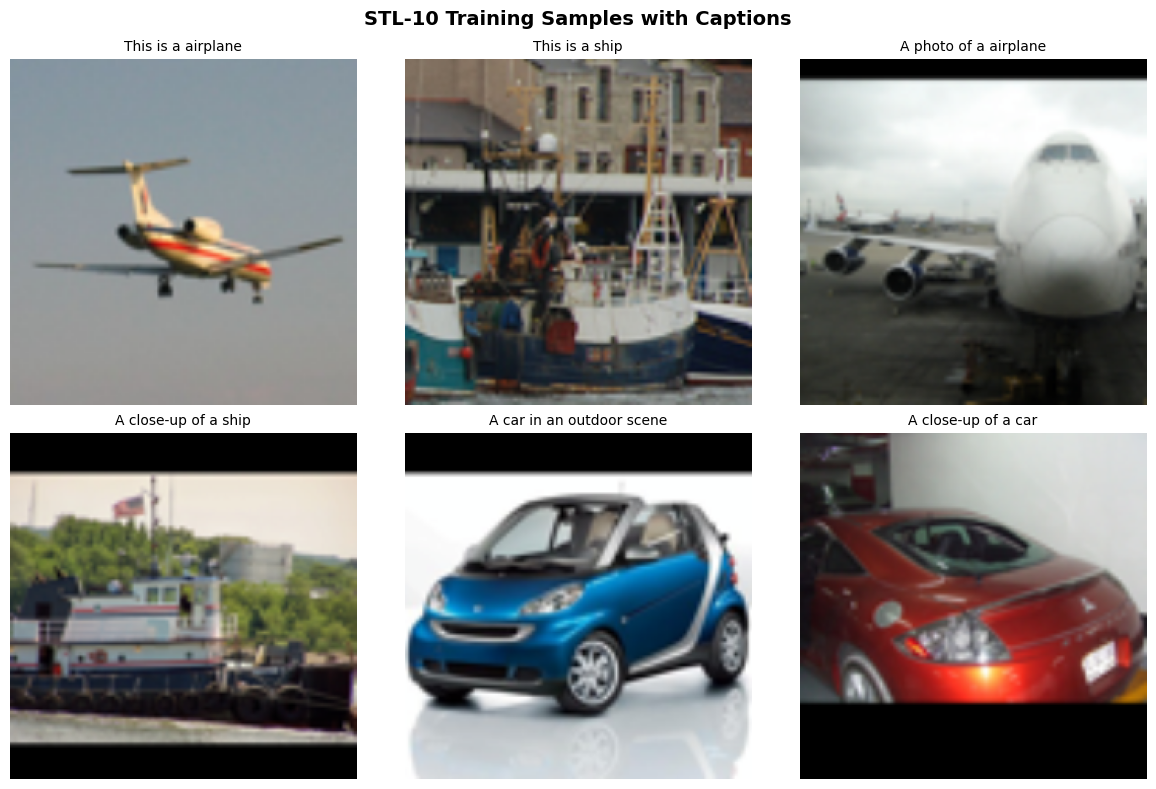

In [ ]:
def denormalize_image(tensor_image):
    """Convert a normalized tensor image back to [0,1] range for visualization."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    image = tensor_image.numpy().transpose(1, 2, 0)
    image = std * image + mean
    return np.clip(image, 0, 1)


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
indices = np.random.choice(len(train_subset), 6, replace=False)

for i, idx in enumerate(indices):
    image, caption = train_subset[idx]
    axes[i].imshow(denormalize_image(image))
    axes[i].set_title(caption, fontsize=10)
    axes[i].axis('off')

plt.suptitle('STL-10 Training Samples with Captions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="section-3"></a>
## Section 3: Train the Diffusion Prior Model

The **Diffusion Prior** learns to map **text embeddings → image embeddings** using a transformer architecture.  
Unlike standard diffusion models that predict noise, the UnCLIP prior predicts **clean image embeddings** from noisy ones conditioned on text.

### Pipeline:
1. Encode text and images with **CLIP** → `z_t`, `z_i`
2. Optionally reduce embedding dimensionality with **trainable projections** (replacing PCA from the paper)
3. Train a transformer to denoise `z_i` conditioned on `z_t` and timestep

In [3]:
# Variance Scheduler (cosine schedule, as per the UnCLIP paper)
prior_scheduler = SchedulerUnCLIP(
    schedule_type="cosine",
    train_steps=1000,
    sample_steps=1000,
    beta_min=1e-4,
    beta_max=0.02
)

# Forward and Reverse Diffusion
prior_fwd = ForwardUnCLIP(prior_scheduler, pred_type="x0")  # Prior predicts x0 (clean embeddings)
prior_rwd = ReverseUnCLIP(prior_scheduler, pred_type="x0")

# CLIP Encoder (frozen, used for text and image embeddings)
clip_encoder = CLIPEncoder(model_name="openai/clip-vit-base-patch32", device=device)

# Trainable Projection Networks (replace PCA from the original paper)
text_projection = CLIPEmbeddingProjection(
    clip_embed_dim=512,
    trans_embed_dim=320,
    hidden_dim=480,
    num_layers=2,
    dropout=0.1,
    use_layer_norm=True
)

image_projection = CLIPEmbeddingProjection(
    clip_embed_dim=512,
    trans_embed_dim=320,
    hidden_dim=480,
    num_layers=2,
    dropout=0.1,
    use_layer_norm=True
)

# Transformer Prior Model
prior_model = UnCLIPTransformerPrior(
    fwd_unclip=prior_fwd,
    rwd_unclip=prior_rwd,
    clip_text_proj=text_projection,
    clip_img_proj=image_projection,
    trans_embed_dim=320,
    num_layers=12,
    num_att_heads=8,
    ff_dim=512,
    max_sequence_length=2,
    dropout=0.3,
    use_flash=True,
    grad_check=False
)

# Optimizer and Loss
prior_optimizer = torch.optim.AdamW(
    [p for p in prior_model.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=0.01
)
prior_loss_fn = nn.MSELoss()

# Count parameters
num_prior_params = sum(p.numel() for p in prior_model.parameters() if p.requires_grad)
print(f"Prior model trainable parameters: {num_prior_params:,}")

Prior model trainable parameters: 10,801,728


In [4]:
prior_trainer = TrainUnCLIPPrior(
    prior_net=prior_model,
    clip_net=clip_encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    optim=prior_optimizer,
    loss_fn=prior_loss_fn,
    max_epochs=50,
    device=device,
    grad_acc=2,
    warmup_steps=500,
    patience=15,
    val_freq=5,
    log_freq=1,
    store_path="prior_model",
    use_ddp=False,
    use_comp=False,
    norm_range=(-1.0, 1.0),
    reduce_clip_embed_dim=True,
    trans_embed_dim=320,
    norm_clip_embed=True,
    use_autocast=True
)

print(f"Total trainer parameters: {sum(p.numel() for p in prior_trainer.parameters()):,}")
print("\nStarting Prior training...")
#prior_losses = prior_trainer() # uncomment to train 

Total trainer parameters: 162,079,041

Starting Prior training...


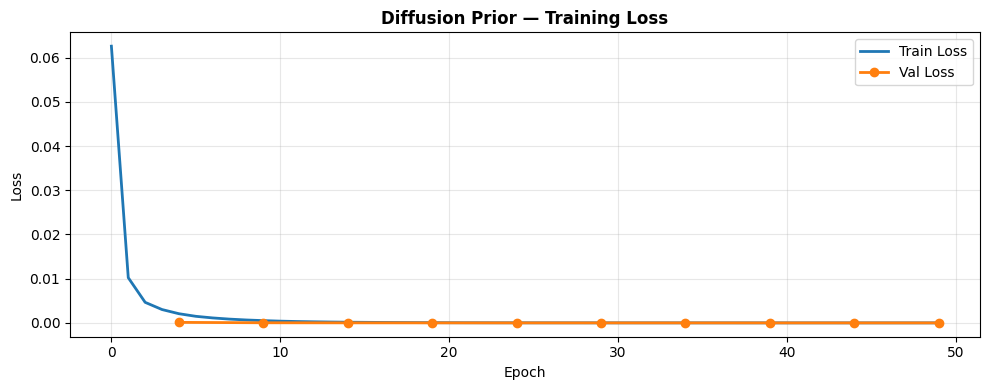

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(prior_losses['train_losses'], label='Train Loss', linewidth=2)
if prior_losses.get('val_losses'):
    plt.plot(
        range(4, len(prior_losses['train_losses']), 5),
        prior_losses['val_losses'],
        label='Val Loss', linewidth=2, marker='o'
    )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion Prior \u2014 Training Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="section-4"></a>
## Section 4: Train the Decoder Model

The **Decoder** converts CLIP image embeddings into **64×64 images** using a conditional diffusion process.

### Decoder Forward Pass:
1. **Project** CLIP image embeddings into 4 context tokens (`C`)
2. **Encode** text with a GLIDE-like transformer encoder → `E`
3. **Concatenate** `E` and `C` → context embeddings
4. **Add noise** to clean images and predict noise with a U-Net conditioned on context + timestep

The decoder uses **classifier-free guidance** (10% embedding dropout) and **text dropout** (50%) as specified in the paper.

In [4]:
# U-Net noise predictor for the decoder
noise_predictor = DiffusionNetwork(
    in_channels=3,
    down_channels=[16, 32, 64],
    mid_channels=[64, 64],
    up_channels=[64, 32, 16],
    down_sampling=[True, True],
    time_embed_dim=512,
    y_embed_dim=512,
    num_down_blocks=1,
    num_mid_blocks=1,
    num_up_blocks=1,
    down_sampling_factor=2
)

# Variance Scheduler for Decoder
decoder_scheduler = SchedulerUnCLIP(
    schedule_type="cosine",
    train_steps=500,
    sample_steps=100,
    beta_min=1e-4,
    beta_max=0.02
)

decoder_fwd = ForwardUnCLIP(decoder_scheduler, pred_type="noise")
decoder_rwd = ReverseUnCLIP(decoder_scheduler, pred_type="noise")

# GLIDE-like Text Encoder for the decoder
glide_text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=1,
    input_dimension=512,
    output_dimension=512,
    num_heads=1,
    context_length=77
)

# Decoder Model
decoder_model = UnClipDecoder(
    clip_embed_dim=512,
    diff_net=noise_predictor,
    fwd_unclip=decoder_fwd,
    rwd_unclip=decoder_rwd,
    glide_text_encoder=glide_text_encoder,
    tokenizer=None,
    device=device,
    norm_range=(-1.0, 1.0),
    norm_clip_embed=True,
    classifier_free_prop=0.1,
    drop_caption=0.5,
    max_token_length=77
)

# Decoder Optimizer and Loss
decoder_optimizer = torch.optim.AdamW(
    [p for p in decoder_model.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=0.01
)
decoder_loss_fn = nn.MSELoss()

# Evaluation Metrics (LPIPS, MSE, PSNR, SSIM)
# metrics = Metrics(device="cpu", fid=False, metrics=True, lpips_=True)

total_params = sum(p.numel() for p in decoder_model.parameters())
trainable_params = sum(p.numel() for p in decoder_model.parameters() if p.requires_grad)
print(f"Decoder total params: {total_params:,} | Trainable: {trainable_params:,}")

Decoder total params: 112,243,411 | Trainable: 2,761,171


In [6]:
# initialize Decoder Trainer and Start Training
decoder_trainer = TrainUnClipDecoder(
    clip_embed_dim=512,
    decoder_net=decoder_model,
    clip_net=clip_encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    optim=decoder_optimizer,
    loss_fn=decoder_loss_fn,
    clip_text_proj=text_projection,
    clip_img_proj=image_projection,
    metrics_=None, # metrics,
    max_epochs=50,
    device=device,
    grad_acc=2,
    warmup_steps=500,
    patience=15,
    val_freq=5,
    log_freq=1,
    store_path="decoder_model",
    use_ddp=False,
    use_comp=False,
    norm_range=(-1.0, 1.0),
    reduce_clip_embed_dim=True,
    trans_embed_dim=320,
    norm_clip_embed=True,
    finetune_clip_proj=False,
    use_autocast=True
)

print(f"Decoder trainer total params: {sum(p.numel() for p in decoder_trainer.parameters()):,}")
print("\nStarting Decoder training...")
# decoder_losses = decoder_trainer() # uncomment to train 

Decoder trainer total params: 264,634,068

Starting Decoder training...


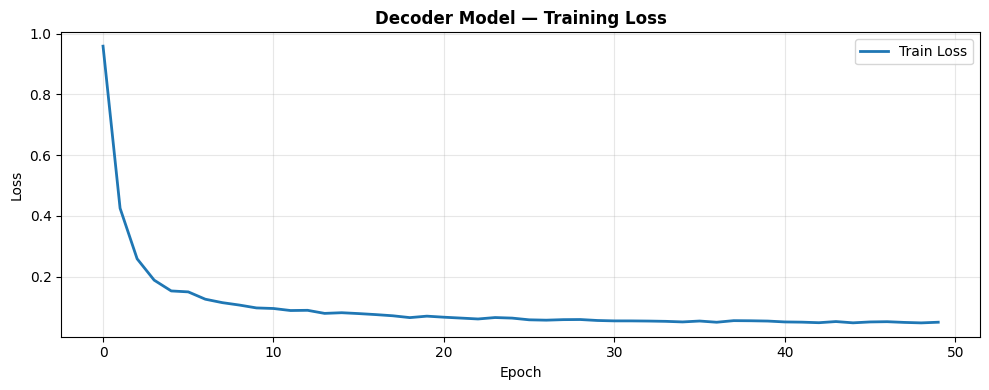

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_losses['train_losses'], label='Train Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Decoder Model \u2014 Training Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="section-5"></a>
## Section 5: Train the Upsampler (64×64 → 256×256)

The UnCLIP model uses a **diffusion-based upsampler** to enhance image resolution.
The upsampler takes the decoder's 64×64 output and produces 256×256 images.

It is a U-Net conditioned on:
- The noisy high-resolution image
- The low-resolution image (bicubic-upsampled to match)
- Diffusion timestep

During training, **Gaussian blur** is applied to low-resolution conditioning images for robustness.

> **Note:** The original paper uses two upsamplers (64→256→1024). We use a single upsampler here
> to keep training feasible on a 4 GB GPU. The architecture is identical — a second upsampler
> can be added for higher resolution if more GPU memory is available.

In [5]:
class UpsampleDataset(Dataset):
    """Generates paired low-res and high-res images from STL-10.

    Low-res: 64x64 (decoder output size)
    High-res: 256x256 (first upsampler target)
    """

    def __init__(self, stl10_dataset, low_res=64, high_res=256):
        self.dataset = stl10_dataset
        self.low_transform = transforms.Compose([
            transforms.Resize((low_res, low_res)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])
        self.high_transform = transforms.Compose([
            transforms.Resize((high_res, high_res)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset.data[idx]
        image = Image.fromarray(np.transpose(image, (1, 2, 0)))  # STL-10: (C,H,W) -> (H,W,C)
        low_res  = self.low_transform(image)
        high_res = self.high_transform(image)
        return low_res, high_res


# Create upsampler datasets from raw STL-10
stl10_raw_train = datasets.STL10(root='./data', split='train', download=False)
stl10_raw_test  = datasets.STL10(root='./data', split='test',  download=False)

up1_train_ds = UpsampleDataset(stl10_raw_train, low_res=64, high_res=256)
up1_val_ds   = UpsampleDataset(stl10_raw_test,  low_res=64, high_res=256)

# Use subsets
up1_train_subset = Subset(up1_train_ds, torch.randperm(len(up1_train_ds))[:2000])
up1_val_subset   = Subset(up1_val_ds,   torch.randperm(len(up1_val_ds))[:500])

# NOTE: num_workers=0 avoids multiprocessing assertion errors during validation in notebooks
up1_train_loader = DataLoader(up1_train_subset, batch_size=2, shuffle=True, num_workers=0, pin_memory=True)
up1_val_loader   = DataLoader(up1_val_subset,   batch_size=2, shuffle=False, num_workers=0, pin_memory=True)

print(f"Upsampler 1 dataset: {len(up1_train_subset)} train, {len(up1_val_subset)} val")

Upsampler 1 dataset: 2000 train, 500 val


In [7]:
up1_scheduler = SchedulerUnCLIP(
    schedule_type="cosine",
    train_steps=400,
    sample_steps=50,
    beta_min=1e-4,
    beta_max=0.02
)

up1_fwd = ForwardUnCLIP(up1_scheduler, pred_type="noise")
up1_rwd = ReverseUnCLIP(up1_scheduler, pred_type="noise")

upsampler_one = UpsamplerUnCLIP(
    fwd_unclip=up1_fwd,
    rwd_unclip=up1_rwd,
    in_channels=3,
    out_channels=3,
    model_channels=32,
    num_res_blocks=2,
    channel_mult=(1, 2, 4, 8),
    dropout=0.1,
    time_embed_dim=32,
    low_res_size=64,
    high_res_size=256
)

up1_optimizer = torch.optim.AdamW(upsampler_one.parameters(), lr=1e-4, weight_decay=0.01)
up1_loss_fn = nn.MSELoss()

total_p = sum(p.numel() for p in upsampler_one.parameters())
print(f"First Upsampler parameters: {total_p:,}")

First Upsampler parameters: 12,808,131


In [9]:
up1_trainer = TrainUpsamplerUnCLIP(
    up_net=upsampler_one,
    train_loader=up1_train_loader,
    optim=up1_optimizer,
    loss_fn=up1_loss_fn,
    val_loader=up1_val_loader,
    max_epochs=50,
    device=device,
    store_path="upsampler_one",
    patience=50,
    warmup_steps=500,
    val_freq=10,
    use_ddp=False,
    grad_acc=2,
    log_freq=1,
    use_comp=False,
    norm_range=(-1.0, 1.0),
    norm_out=True,
    use_autocast=False
)

print("Starting First Upsampler training...")
# up1_losses = up1_trainer() # uncomment to train 

Starting First Upsampler training...


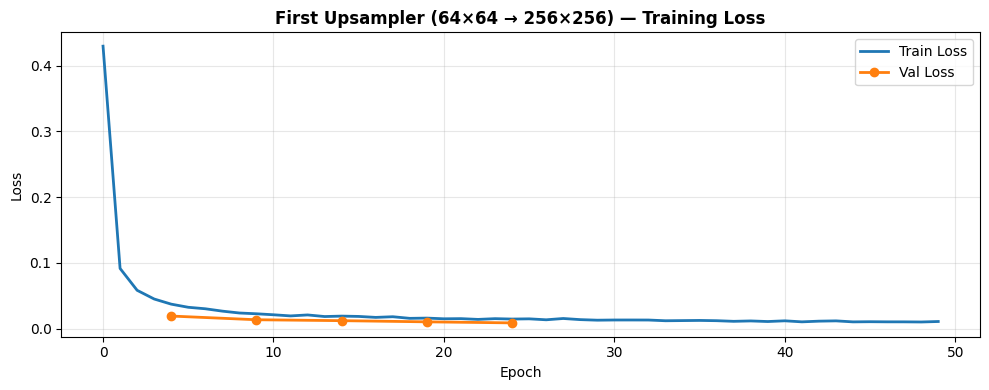

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(up1_losses['train_losses'], label='Train Loss', linewidth=2)
if up1_losses.get('val_losses'):
    val_epochs = list(range(4, len(up1_losses['train_losses']), 5))
    plt.plot(val_epochs[:len(up1_losses['val_losses'])], up1_losses['val_losses'],
             label='Val Loss', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('First Upsampler (64\u00d764 \u2192 256\u00d7256) \u2014 Training Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id="section-6"></a>
## Section 6: Sampling Pipeline

With all three components trained, we can now generate images from text prompts using the UnCLIP pipeline:

1. **Prior Model**: Text prompt → CLIP text embedding → predicted image embedding
2. **Decoder**: Image embedding → 64×64 image
3. **Upsampler**: 64×64 → 256×256

The `SampleUnCLIP` class orchestrates this entire pipeline with **model offloading** to keep GPU memory under control.

In [8]:
import torch
from torchdiff.unclip import CLIPContextProjection

# load prior model weights 
prior_ckpt_path = "prior_model/model_epoch_50.pth"
prior_ckpt = torch.load(prior_ckpt_path, map_location=device, weights_only=False)
prior_model.load_state_dict(prior_ckpt['prior_net_state_dict'])
prior_model.to(device).eval()
print(f"✓ Prior loaded from {prior_ckpt_path}  (epoch {prior_ckpt['epoch']}, loss {prior_ckpt['loss']:.4f})")

# load decoder model weights
dec_ckpt_path = "decoder_model/model_epoch_50.pth"
dec_ckpt = torch.load(dec_ckpt_path, map_location=device, weights_only=False)


decoder_model.clip_decoder_proj = CLIPContextProjection(
    clip_embed_dim=320, num_tokens=4, output_dim=512
).to(device)
decoder_model.clip_time_proj = torch.nn.Linear(320, 512).to(device)

decoder_model.diff_net.load_state_dict(dec_ckpt['diff_net_state_dict'])
decoder_model.glide_text_encoder.load_state_dict(dec_ckpt['cond_model_state_dict'])
decoder_model.clip_time_proj.load_state_dict(dec_ckpt['clip_time_proj_state_dict'])
decoder_model.clip_decoder_proj.load_state_dict(dec_ckpt['decoder_proj_state_dict'])

# load the CLIP projection layers (text & image)
if 'text_proj_state_dict' in dec_ckpt:
    text_projection.load_state_dict(dec_ckpt['text_proj_state_dict'])
if 'img_proj_state_dict' in dec_ckpt:
    image_projection.load_state_dict(dec_ckpt['img_proj_state_dict'])

decoder_model.to(device).eval()
text_projection.to(device).eval()
image_projection.to(device).eval()
print(f"✓ Decoder loaded from {dec_ckpt_path}  (epoch {dec_ckpt['epoch']}, loss {dec_ckpt['loss']:.4f})")

# load upsampler weights
up1_ckpt_path = "upsampler_one/model_epoch_50.pth"
up1_ckpt = torch.load(up1_ckpt_path, map_location=device, weights_only=False)
upsampler_one.load_state_dict(up1_ckpt['up_net_state_dict'])
upsampler_one.to(device).eval()
print(f"✓ Upsampler loaded from {up1_ckpt_path}  (epoch {up1_ckpt['epoch']}, loss {up1_ckpt['loss']:.4f})")

print("\nAll models loaded and ready for sampling!")

✓ Prior loaded from prior_model/model_epoch_50.pth  (epoch 50, loss 0.0000)
✓ Decoder loaded from decoder_model/model_epoch_50.pth  (epoch 50, loss 0.0505)
✓ Upsampler loaded from upsampler_one/model_epoch_50.pth  (epoch 50, loss 0.0107)

All models loaded and ready for sampling!


In [13]:
unclip_sampler = SampleUnCLIP(
    prior_net=prior_model,
    decoder_net=decoder_model,
    clip_net=clip_encoder,
    low_res_upsampler=upsampler_one,
    high_res_upsampler=None,
    device=device,
    offload_device='cpu',
    clip_embed_dim=512,
    prior_guidance_scale=4.0,
    decoder_guidance_scale=8.0,
    batch_size=1,
    norm_clip_embed=True,
    prior_dim_reduction=True,
    init_img_size=(3, 64, 64),
    use_high_res_upsampler=False,
    norm_range=(-1.0, 1.0),
    use_model_offloading=True
)

total_sampler_params = sum(p.numel() for p in unclip_sampler.parameters())
print(f"Total parameters in sampling pipeline: {total_sampler_params:,}")

Total parameters in sampling pipeline: 286,639,063


In [14]:
test_prompts = [
    "A photo of a cat",
    "An airplane in the sky",
    "A dog running",
    "A red bird",
    "A blue car",
    "A horse in a field",
]

os.makedirs("samples/imgs_256", exist_ok=True)

for idx, prompt in enumerate(test_prompts):
    print(f"\nGenerating: '{prompt}'")
    generated = unclip_sampler(
        prompts=[prompt],
        norm_output=True,
        save_imgs=False,  # we save manually with unique names
        save_path="samples"
    )
    # save with unique per-prompt filename
    torchvision.utils.save_image(generated[0], f"samples/imgs_256/img_{idx+1}.png")
    print(f"  Output shape: {generated.shape}  →  saved as img_{idx+1}.png")


Generating: 'A photo of a cat'


Prior diffusion:   0%|          | 0/999 [00:00<?, ?it/s]

Decoder 64x64:   0%|          | 0/99 [00:00<?, ?it/s]

Upsampler 256x256:   0%|          | 0/49 [00:00<?, ?it/s]

  Output shape: torch.Size([1, 3, 256, 256])  →  saved as img_1.png

Generating: 'An airplane in the sky'


...

  Output shape: torch.Size([1, 3, 256, 256])  →  saved as img_5.png

Generating: 'A horse in a field'


Prior diffusion:   0%|          | 0/999 [00:00<?, ?it/s]

Decoder 64x64:   0%|          | 0/99 [00:00<?, ?it/s]

Upsampler 256x256:   0%|          | 0/49 [00:00<?, ?it/s]

  Output shape: torch.Size([1, 3, 256, 256])  →  saved as img_6.png


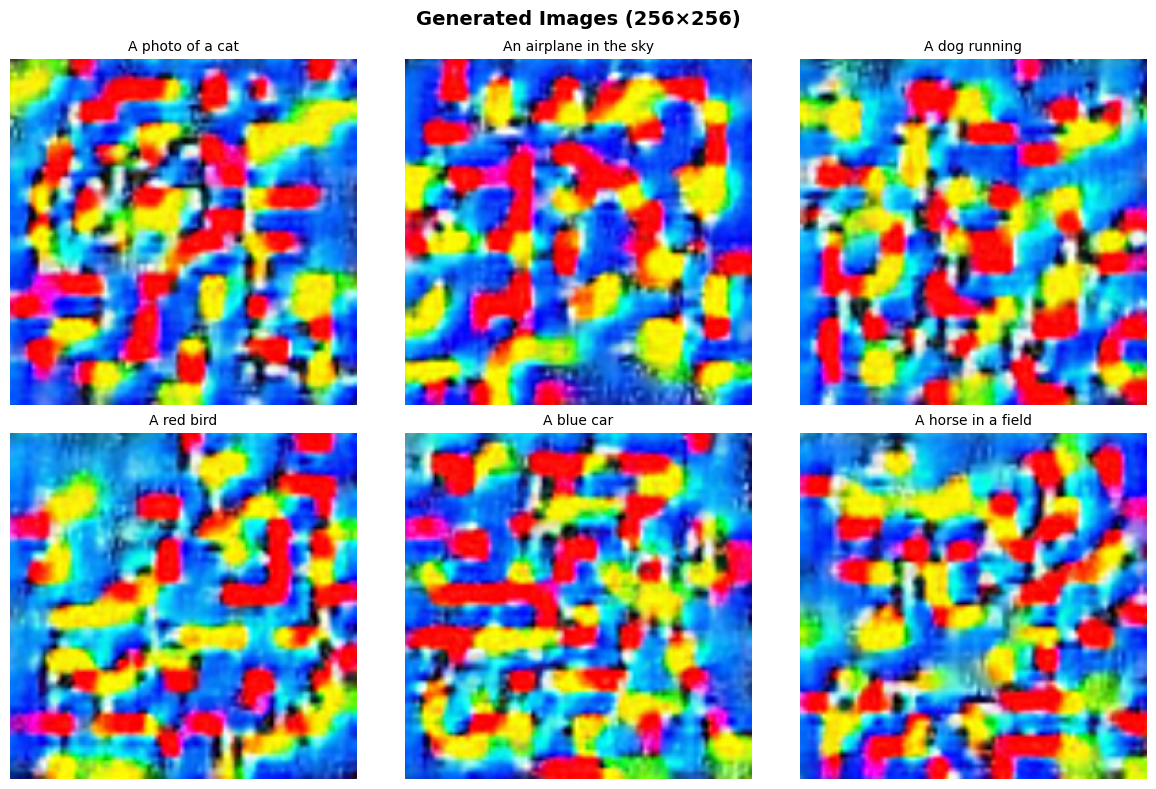

In [20]:
imgs_256_path = "samples/imgs_256"
if os.path.exists(imgs_256_path):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    for i in range(min(6, len(os.listdir(imgs_256_path)))):
        img_path = os.path.join(imgs_256_path, f"img_{i+1}.png")
        if os.path.exists(img_path):
            img = plt.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(test_prompts[i] if i < len(test_prompts) else '', fontsize=10)
            axes[i].axis('off')
    plt.suptitle('Generated Images (256×256)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No generated images found. Run the sampling cell first.")

<a id="section-7"></a>
## Section 7: Analysis and Evaluation

### Training Summary

Let's consolidate and compare the training curves of all three components to assess convergence.

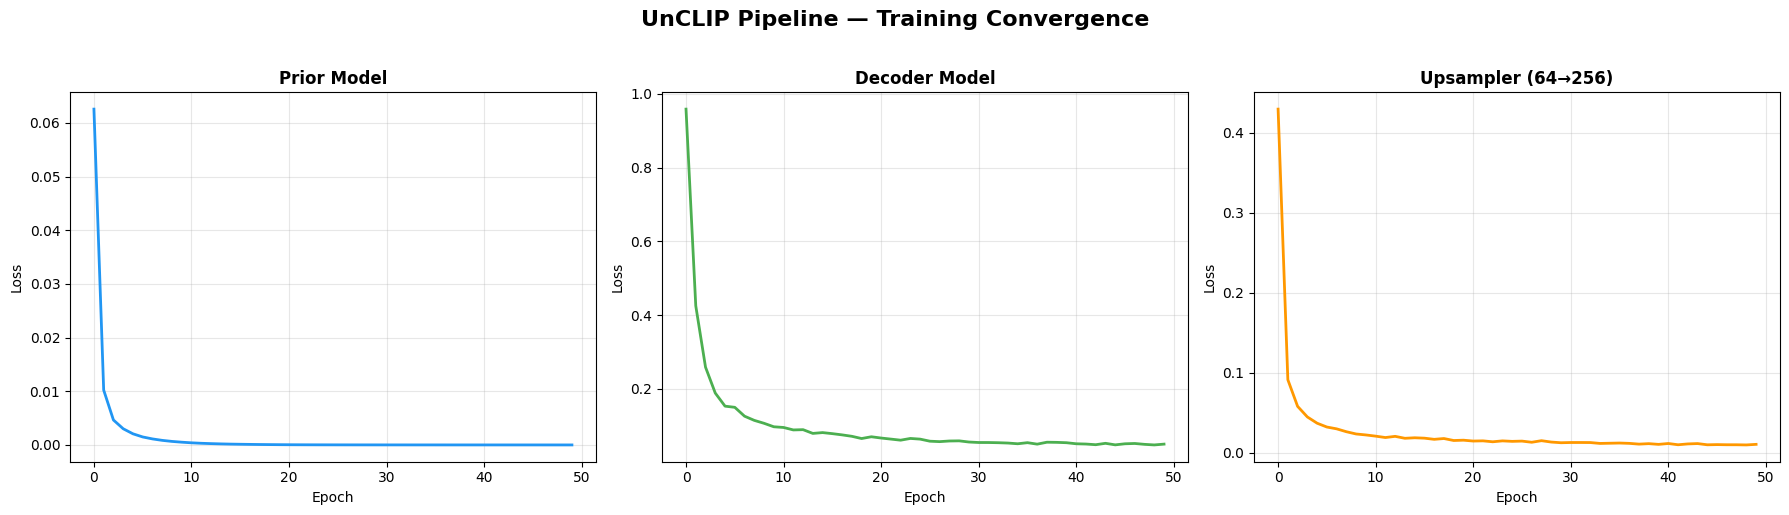

In [21]:

# use losses from loaded checkpoints (works after kernel restart)
prior_losses = prior_ckpt['losses']
decoder_losses = dec_ckpt['losses']
up1_losses = up1_ckpt['losses']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prior
axes[0].plot(prior_losses['train_losses'], linewidth=2, color='#2196F3')
axes[0].set_title('Prior Model', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Decoder
axes[1].plot(decoder_losses['train_losses'], linewidth=2, color='#4CAF50')
axes[1].set_title('Decoder Model', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# Upsampler
axes[2].plot(up1_losses['train_losses'], linewidth=2, color='#FF9800')
axes[2].set_title('Upsampler (64→256)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)

plt.suptitle('UnCLIP Pipeline — Training Convergence', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL SIZE COMPARISON
  CLIP Encoder (frozen)           151,277,313 params
  Prior Model                      10,801,728 params
  Decoder Model                   111,751,891 params
  Upsampler (64→256)               12,808,131 params
------------------------------------------------------------
  TOTAL                           286,639,063 params
  Approx. model size                 1146.6 MB (fp32)


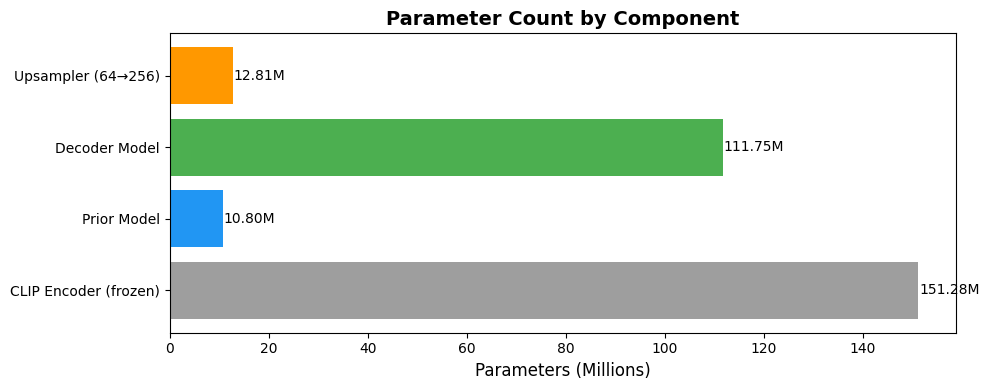

In [22]:
components = {
    'CLIP Encoder (frozen)': sum(p.numel() for p in clip_encoder.parameters()),
    'Prior Model': sum(p.numel() for p in prior_model.parameters()),
    'Decoder Model': sum(p.numel() for p in decoder_model.parameters()),
    'Upsampler (64→256)': sum(p.numel() for p in upsampler_one.parameters()),
}

print("=" * 60)
print("MODEL SIZE COMPARISON")
print("=" * 60)
total = 0
for name, count in components.items():
    print(f"  {name:<30} {count:>12,} params")
    total += count
print("-" * 60)
print(f"  {'TOTAL':<30} {total:>12,} params")
print(f"  {'Approx. model size':<30} {total * 4 / 1e6:>10.1f} MB (fp32)")
print("=" * 60)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
names = list(components.keys())
counts = [v / 1e6 for v in components.values()]
colors = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF9800']
bars = ax.barh(names, counts, color=colors)
ax.set_xlabel('Parameters (Millions)', fontsize=12)
ax.set_title('Parameter Count by Component', fontsize=14, fontweight='bold')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{count:.2f}M', va='center', fontsize=10)
plt.tight_layout()
plt.show()

FINAL TRAINING STATISTICS

  Prior:
    Initial loss:  0.062578
    Final loss:    0.000001
    Best loss:     0.000001
    Epochs trained: 50
    Loss reduction: 100.0%

  Decoder:
    Initial loss:  0.958492
    Final loss:    0.050485
    Best loss:     0.048304
    Epochs trained: 50
    Loss reduction: 94.7%

  Upsampler:
    Initial loss:  0.429849
    Final loss:    0.010654
    Best loss:     0.009927
    Epochs trained: 50
    Loss reduction: 97.5%

GENERATED IMAGE ANALYSIS

  A photo of a cat:
    Shape: (256, 256, 3)
    Pixel range: [0.000, 1.000]
    Mean: 0.492  |  Std: 0.367
    Per-channel mean (R/G/B): 0.444 / 0.474 / 0.559

  An airplane in the sky:
    Shape: (256, 256, 3)
    Pixel range: [0.000, 1.000]
    Mean: 0.486  |  Std: 0.380
    Per-channel mean (R/G/B): 0.448 / 0.451 / 0.558

  A dog running:
    Shape: (256, 256, 3)
    Pixel range: [0.000, 1.000]
    Mean: 0.500  |  Std: 0.369
    Per-channel mean (R/G/B): 0.452 / 0.503 / 0.545

  A red bird:
    Shape: 

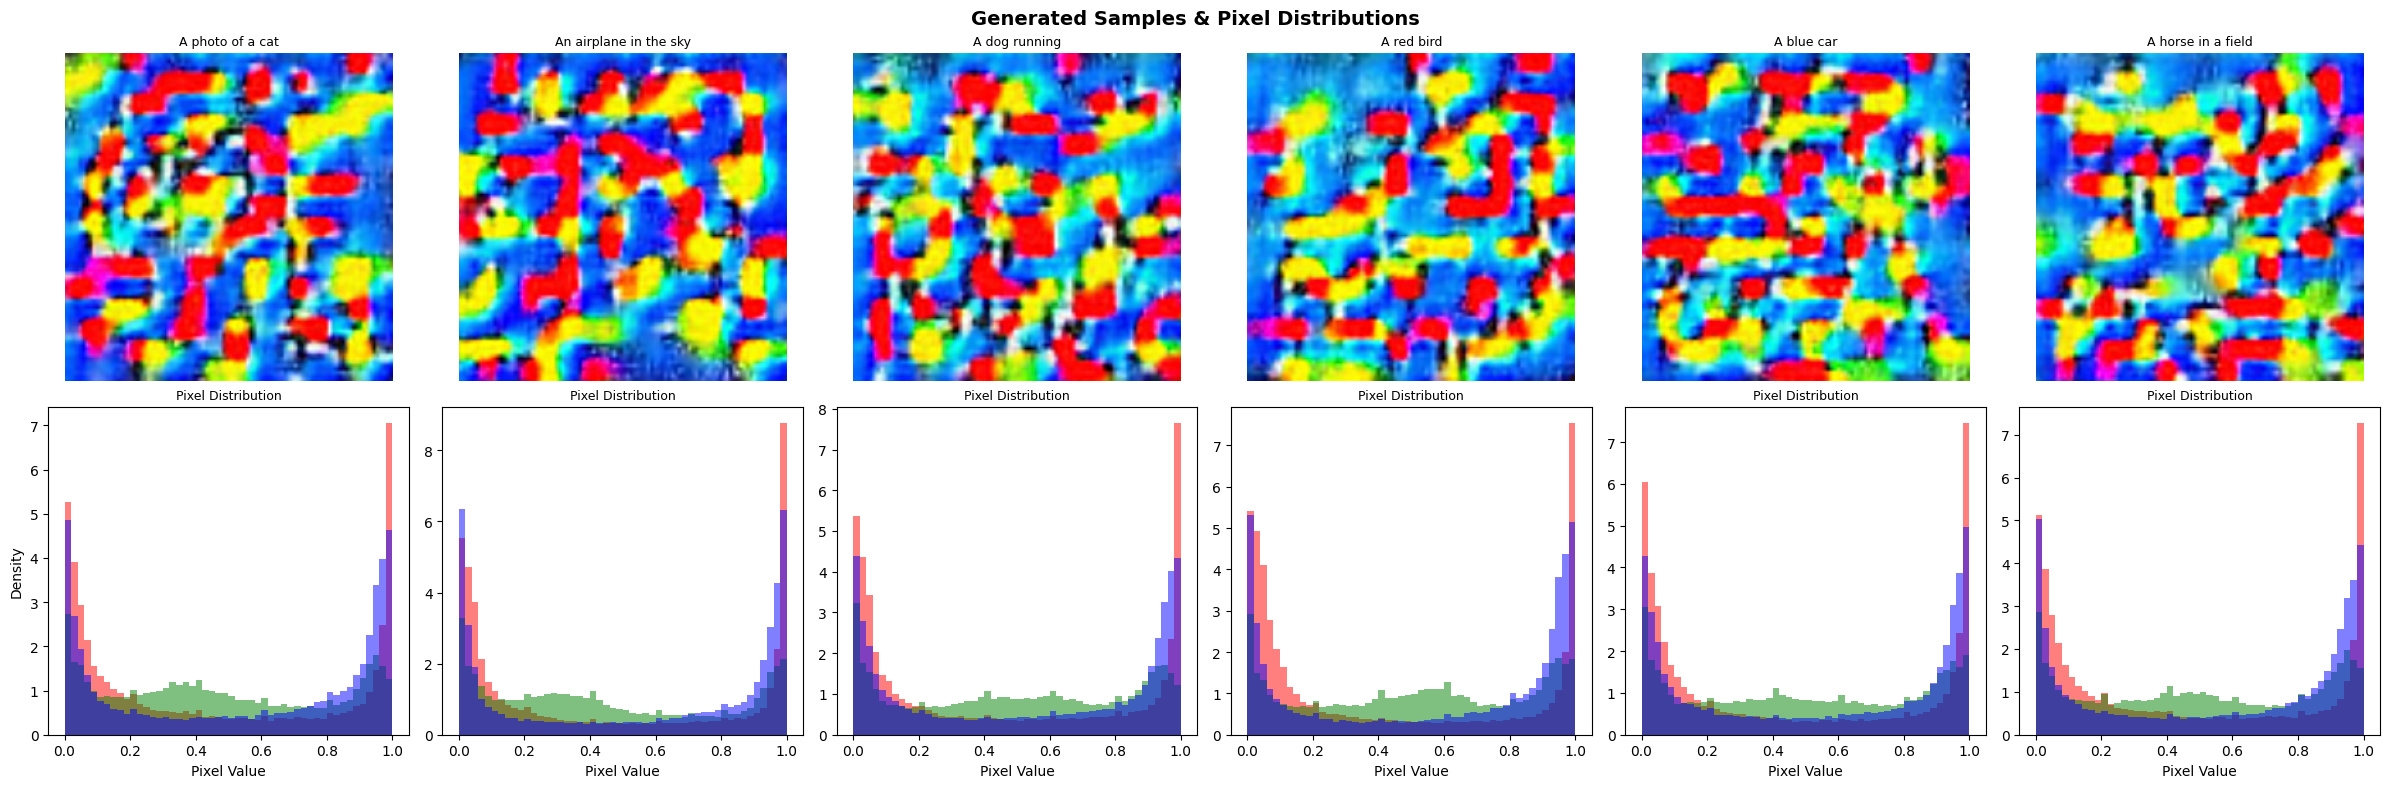

In [23]:
print("=" * 70)
print("FINAL TRAINING STATISTICS")
print("=" * 70)

stats = [
    ('Prior',     prior_losses['train_losses']),
    ('Decoder',   decoder_losses['train_losses']),
    ('Upsampler', up1_losses['train_losses']),
]

for name, losses in stats:
    print(f"\n  {name}:")
    print(f"    Initial loss:  {losses[0]:.6f}")
    print(f"    Final loss:    {losses[-1]:.6f}")
    print(f"    Best loss:     {min(losses):.6f}")
    print(f"    Epochs trained: {len(losses)}")
    reduction = (1 - losses[-1] / losses[0]) * 100 if losses[0] != 0 else 0
    print(f"    Loss reduction: {reduction:.1f}%")



print("\n" + "=" * 70)
print("GENERATED IMAGE ANALYSIS")
print("=" * 70)

imgs_256_path = "samples/imgs_256"
if os.path.exists(imgs_256_path):
    sample_files = sorted([f for f in os.listdir(imgs_256_path) if f.endswith('.png')])

    fig, axes = plt.subplots(2, len(sample_files), figsize=(4 * len(sample_files), 8))

    for i, fname in enumerate(sample_files):
        img = plt.imread(os.path.join(imgs_256_path, fname))

        # Top row: generated images
        axes[0, i].imshow(img)
        axes[0, i].set_title(test_prompts[i] if i < len(test_prompts) else '', fontsize=9)
        axes[0, i].axis('off')

        # Bottom row: per-channel histograms
        for c, color in enumerate(['red', 'green', 'blue']):
            axes[1, i].hist(img[:, :, c].ravel(), bins=50, color=color, alpha=0.5, density=True)
        axes[1, i].set_title('Pixel Distribution', fontsize=9)
        axes[1, i].set_xlabel('Pixel Value')
        if i == 0:
            axes[1, i].set_ylabel('Density')

        # Print stats
        print(f"\n  {test_prompts[i] if i < len(test_prompts) else fname}:")
        print(f"    Shape: {img.shape}")
        print(f"    Pixel range: [{img.min():.3f}, {img.max():.3f}]")
        print(f"    Mean: {img.mean():.3f}  |  Std: {img.std():.3f}")
        print(f"    Per-channel mean (R/G/B): "
              f"{img[:,:,0].mean():.3f} / {img[:,:,1].mean():.3f} / {img[:,:,2].mean():.3f}")

    plt.suptitle('Generated Samples & Pixel Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("  No generated images found.")

print("\n" + "=" * 70)

### Observations on Generated Images

The generated samples appear as **noisy, colorful patterns** without recognizable structure. This is **expected behavior** given the constraints of this tutorial setup:

#### Why the Outputs Look This Way

| Factor | This Tutorial | Production UnCLIP (DALL·E 2) |
|--------|--------------|------------------------------|
| **Training data** | 2,000 images (STL-10 subset) | 400M+ image-text pairs (LAION) |
| **Training epochs** | 50 per component | 500,000+ steps |
| **Decoder U-Net** | 3 down/up channels (16→64) | 256+ channels, attention at multiple resolutions |
| **Prior model** | 12-layer transformer, dim=320 | 24+ layers, dim=2048 |
| **Upsampler** | 32 base channels | 256+ base channels, cascaded |
| **GPU memory** | 4 GB | 8× A100 (640 GB total) |

#### What the Training Curves Tell Us

- **Prior** (loss → ~0.000001): Converged very well — the prior learned to map text embeddings to image embedding space. However, with only 2,000 training pairs covering 10 classes, the embedding space is extremely sparse.
- **Decoder** (loss 0.96 → 0.05): Strong convergence (94.7% reduction), but the model capacity (16/32/64 channels) is too small to reconstruct complex images. It learned basic color patterns from the noise prediction task but cannot recover fine spatial structure.
- **Upsampler** (loss 0.43 → 0.01): Good convergence (97.5% reduction), but it amplifies artifacts from the decoder's noisy 64×64 output rather than adding meaningful detail.

#### Key Takeaway

The pipeline is **functionally correct** — all three stages (prior → decoder → upsampler) execute end-to-end and produce outputs. The low visual quality is purely a capacity/data limitation, not a code issue. The training losses confirm each component is learning its objective. For recognizable generations, scale up the model sizes, dataset, and training duration as described above.

#### Improving Results (Practical Steps)

1. **Quick win**: Train for 500+ epochs on the full STL-10 train set (5,000 images)
2. **Medium effort**: Use COCO Captions (330K images) with real captions, increase U-Net to 64/128/256 channels
3. **Full scale**: Use LAION-5B, larger prior (24 layers, dim=1024+), and multi-GPU training with `use_ddp=True`

<a id="useful-links"></a>

---

## Useful Links and References

### TorchDiff Resources
- [TorchDiff Website](https://loqmansamani.github.io/torchdiff/) \u2014 Official project page
- [TorchDiff GitHub Repository](https://github.com/LoqmanSamani/TorchDiff) \u2014 Source code
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html) \u2014 Full API reference
- [TorchDiff on PyPI](https://pypi.org/project/torchdiff/) \u2014 Install with `pip install torchdiff`

### Key Papers
- [Hierarchical Text-Conditional Image Generation with CLIP Latents](https://arxiv.org/abs/2204.06125) (UnCLIP / DALL\u00b7E 2)
- [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) (CLIP)
- [GLIDE: Towards Photorealistic Image Generation and Editing](https://arxiv.org/abs/2112.10741) (GLIDE text encoder)
- [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) (DDPM)
- [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502) (DDIM)

### Datasets
- [STL-10 Dataset](https://cs.stanford.edu/~acoates/stl10/) \u2014 96\u00d796 natural images, 10 classes
- [MS COCO Captions](https://cocodataset.org/) \u2014 330K images with 5 captions each
- [LAION-400M](https://laion.ai/blog/laion-400-open-dataset/) \u2014 Large-scale image-text pairs
- [Flickr30K](https://shannon.cs.illinois.edu/DenotationGraph/) \u2014 31K images with descriptive captions

### Related Tutorials
- [DDPM Tutorial (TorchDiff)](../../examples/ddpm/ddpm.ipynb)
- [DDIM Tutorial (TorchDiff)](../../examples/ddim/ddim.ipynb)
- [LDM Tutorial (TorchDiff)](../../examples/ldm/ldm.ipynb)
- [SDE Tutorial (TorchDiff)](../../examples/sde/)